Automated Pneumonia Detection from Chest X-Ray Images
PyTorch + CUDA implementation (local, RTX 3060)

# Automated Pneumonia Detection from Chest X-Ray Images

**Contributors:** Rajib Roy

End-to-end 3-class chest X-ray classification: **Normal / Pneumonia / COVID-19**

| Stage | Description |
|-------|-------------|
| 1 | Environment and GPU setup |
| 2 | Dataset download (Kermany + COVID-19 Radiography) |
| 3 | Build unified 3-class dataset |
| 4 | Advanced class imbalance handling (Focal Loss + class weights) |
| 5 | Transfer learning: DenseNet121, ResNet50, EfficientNetB0 |
| 6 | Ensemble weighted soft voting |
| 7 | Uncertainty quantification (MC Dropout) |
| 8 | Class-specific Grad-CAM explainability |
| 9 | Full evaluation: metrics, ROC, calibration, uncertainty analysis |
| 10 | Model export |

## Stage 1 — Environment & GPU Setup

In [1]:
import os, sys, warnings, json, zipfile, shutil, subprocess
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from torch.cuda.amp import GradScaler, autocast
from pathlib import Path
from tqdm import tqdm

# ── GPU setup ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found — running on CPU")

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
print(f"Python  : {sys.version.split()[0]}")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

GPU : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
PyTorch : 2.6.0+cu124
Device  : cuda
Python  : 3.12.1


## Stage 2 — Directory Setup & Dataset Download

In [2]:
BASE_DIR       = Path('..').resolve()
RAW_DIR        = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR  = BASE_DIR / 'data' / 'processed'
MODEL_DIR      = BASE_DIR / 'model'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'

for d in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Directories ready:")
for d in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, CHECKPOINT_DIR]:
    print(f"  {d}")


def kaggle_download(dataset: str, target_dir: Path):
    """Download and extract a Kaggle dataset if not already present."""
    target_dir.mkdir(parents=True, exist_ok=True)
    if list(target_dir.iterdir()):
        print(f"[skip] {dataset} — already at {target_dir}")
        return
    print(f"[download] {dataset} → {target_dir}")
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", dataset,
         "-p", str(target_dir), "--unzip"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Kaggle download failed for {dataset}")
    print(f"[done] {dataset}")


kaggle_download("paultimothymooney/chest-xray-pneumonia",      RAW_DIR / "kermany")
kaggle_download("tawsifurrahman/covid19-radiography-database", RAW_DIR / "covid19")

Directories ready:
  C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\data\raw
  C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\data\processed
  C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\model
  C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\model\checkpoints
[skip] paultimothymooney/chest-xray-pneumonia — already at C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\data\raw\kermany
[skip] tawsifurrahman/covid19-radiography-database — already at C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\data\raw\covid19


## Stage 3 — Build Unified 3-Class Dataset

**Label mapping:**
- `NORMAL`    — Kermany Normal + COVID-19 Radiography Normal
- `PNEUMONIA` — Kermany Pneumonia + Viral Pneumonia + Lung Opacity
- `COVID`     — COVID-19 Radiography COVID class

**Split:** 80 / 10 / 10 stratified train / val / test

In [3]:
from sklearn.model_selection import train_test_split

CLASSES    = ['NORMAL', 'PNEUMONIA', 'COVID']
IMG_SIZE   = (224, 224)

KERMANY_DIR = RAW_DIR / 'kermany' / 'chest_xray'
COVID19_DIR = RAW_DIR / 'covid19' / 'COVID-19_Radiography_Dataset'


def collect_images(directories):
    paths = []
    for d in directories:
        d = Path(d)
        if d.exists():
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
                paths.extend(d.glob(ext))
        else:
            print(f"  [warn] directory not found: {d}")
    return paths


sources = {
    'NORMAL': collect_images([
        KERMANY_DIR / 'train' / 'NORMAL',
        KERMANY_DIR / 'test'  / 'NORMAL',
        COVID19_DIR / 'Normal' / 'images',
    ]),
    'PNEUMONIA': collect_images([
        KERMANY_DIR / 'train' / 'PNEUMONIA',
        KERMANY_DIR / 'test'  / 'PNEUMONIA',
        COVID19_DIR / 'Viral Pneumonia' / 'images',
        COVID19_DIR / 'Lung_Opacity'    / 'images',
    ]),
    'COVID': collect_images([
        COVID19_DIR / 'COVID' / 'images',
    ]),
}


def deduplicate(paths):
    seen, unique = set(), []
    for p in paths:
        if p.stem not in seen:
            seen.add(p.stem)
            unique.append(p)
    return unique


for cls in CLASSES:
    before = len(sources[cls])
    sources[cls] = deduplicate(sources[cls])
    print(f"  {cls:12s}: {before:5d} → {len(sources[cls]):5d} after dedup")

total = sum(len(v) for v in sources.values())
print(f"  TOTAL      : {total}")

# ── Stratified 80/10/10 split ──────────────────────────────────────────────────
all_paths, all_labels = [], []
for cls, paths in sources.items():
    all_paths.extend(paths)
    all_labels.extend([cls] * len(paths))

train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.20, random_state=SEED, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, random_state=SEED, stratify=tmp_labels
)

splits = {
    'train': (train_paths, train_labels),
    'val':   (val_paths,   val_labels),
    'test':  (test_paths,  test_labels),
}

for split, (paths, labels) in splits.items():
    for cls in CLASSES:
        (PROCESSED_DIR / split / cls).mkdir(parents=True, exist_ok=True)
    copied = 0
    for p, lbl in zip(paths, labels):
        dst = PROCESSED_DIR / split / lbl / p.name
        if not dst.exists():
            shutil.copy2(p, dst)
            copied += 1
    print(f"  {split:6s} : {len(paths):5d} images  (copied {copied})")

rows = []
for split in ['train', 'val', 'test']:
    row = {'Split': split}
    for cls in CLASSES:
        row[cls] = len(list((PROCESSED_DIR / split / cls).iterdir()))
    row['Total'] = sum(row[cls] for cls in CLASSES)
    rows.append(row)
print()
print(pd.DataFrame(rows).to_string(index=False))

  NORMAL      : 23534 → 11767 after dedup
  PNEUMONIA   : 23244 → 11622 after dedup
  COVID       :  7232 →  3616 after dedup
  TOTAL      : 27005
  train  : 21604 images  (copied 0)
  val    :  2700 images  (copied 0)
  test   :  2701 images  (copied 0)

Split  NORMAL  PNEUMONIA  COVID  Total
train    9413       9298   2893  21604
  val    1177       1162    361   2700
 test    1177       1162    362   2701


## Stage 4 — Focal Loss, Class Weights & DataLoaders

**Focal Loss** down-weights easy examples and focuses learning on hard ones.
ImageNet normalization (mean/std) used for all pretrained torchvision models.

In [4]:
from sklearn.utils.class_weight import compute_class_weight

# ── Class weights ──────────────────────────────────────────────────────────────
label_array = np.array(train_labels)
cw_values   = compute_class_weight(
    class_weight='balanced',
    classes=np.array(CLASSES),
    y=label_array,
)
class_weights = torch.tensor(cw_values, dtype=torch.float32).to(device)
print("Class weights:", {c: round(float(w), 4) for c, w in zip(CLASSES, cw_values)})


# ── Focal Loss ─────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class weight."""
    def __init__(self, gamma: float = 2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight  # (C,) tensor

    def forward(self, logits, targets):
        # logits: (N, C), targets: (N,) long
        ce   = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-F.cross_entropy(logits, targets, reduction='none'))
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


criterion = FocalLoss(gamma=2.0, weight=class_weights)

# ── ImageNet normalisation ─────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

BATCH = 32

train_tfm = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfm = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(str(PROCESSED_DIR / 'train'), transform=train_tfm)
val_ds   = ImageFolder(str(PROCESSED_DIR / 'val'),   transform=val_tfm)
test_ds  = ImageFolder(str(PROCESSED_DIR / 'test'),  transform=val_tfm)

# ImageFolder sorts classes alphabetically; reorder to match CLASSES
CLASS_TO_IDX = train_ds.class_to_idx          # {'COVID':0, 'NORMAL':1, 'PNEUMONIA':2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
print("class_to_idx:", CLASS_TO_IDX)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}")

Class weights: {'NORMAL': 0.765, 'PNEUMONIA': 0.7745, 'COVID': 2.4892}
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
Train : 21604 | Val : 2700 | Test : 2701


## Stage 5 — Transfer Learning: DenseNet121, ResNet50, EfficientNetB0

Two-phase training:
1. **Phase 1** — frozen backbone, train head only (5 epochs, lr=1e-3)
2. **Phase 2** — unfreeze last block + head (20 epochs, lr=1e-5)

Callbacks: EarlyStopping (patience=5), ReduceLROnPlateau, ModelCheckpoint.
Mixed precision (AMP) enabled for faster CUDA training.

DenseNet121   params: 7,219,587
ResNet50      params: 24,037,955
EfficientNetB0 params: 4,339,327

  DENSENET121 — Phase 1 (frozen backbone, 5 epochs, lr=1e-3)


  Ep  1 | tr_loss=0.2941 tr_acc=0.7502 | vl_loss=0.1960 vl_acc=0.7893


  Ep  2 | tr_loss=0.2098 tr_acc=0.7819 | vl_loss=0.1678 vl_acc=0.8141


  Ep  3 | tr_loss=0.1969 tr_acc=0.7938 | vl_loss=0.1626 vl_acc=0.8152


  Ep  4 | tr_loss=0.1924 tr_acc=0.7965 | vl_loss=0.1519 vl_acc=0.8270


...

  Ep  3 | tr_loss=0.1011 tr_acc=0.8931 | vl_loss=0.0693 vl_acc=0.9356


  Ep  4 | tr_loss=0.0988 tr_acc=0.8964 | vl_loss=0.0716 vl_acc=0.9396


  Ep  5 | tr_loss=0.0960 tr_acc=0.8988 | vl_loss=0.0696 vl_acc=0.9319


  Ep  6 | tr_loss=0.0944 tr_acc=0.9001 | vl_loss=0.0656 vl_acc=0.9270


  Ep  7 | tr_loss=0.0908 tr_acc=0.9028 | vl_loss=0.0659 vl_acc=0.9344
  EarlyStopping (phase 2)

All models trained.


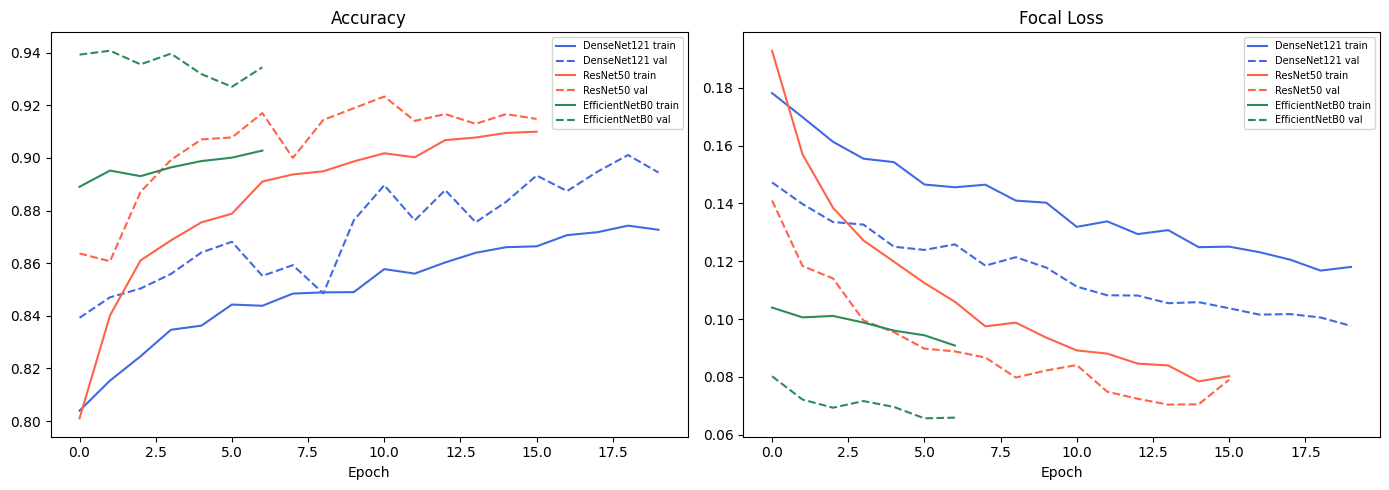

In [5]:
NUM_CLASSES  = 3
DROPOUT_RATE = 0.4


# ── Model builders ─────────────────────────────────────────────────────────────

def build_densenet(num_classes=NUM_CLASSES, dropout=DROPOUT_RATE):
    m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    in_features = m.classifier.in_features          # 1024
    m.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(dropout),
        nn.Linear(256, num_classes),
    )
    return m


def build_resnet(num_classes=NUM_CLASSES, dropout=DROPOUT_RATE):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_features = m.fc.in_features                  # 2048
    m.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(dropout),
        nn.Linear(256, num_classes),
    )
    return m


def build_efficientnet(num_classes=NUM_CLASSES, dropout=DROPOUT_RATE):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = m.classifier[1].in_features       # 1280
    m.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(256),
        nn.Dropout(dropout),
        nn.Linear(256, num_classes),
    )
    return m


def freeze_backbone(model):
    """Freeze all layers except the classifier/fc head."""
    for name, param in model.named_parameters():
        if not any(k in name for k in ['classifier', 'fc']):
            param.requires_grad = False


def unfreeze_last_block(model, model_type: str):
    """Unfreeze the last residual/dense block for fine-tuning."""
    if model_type == 'densenet':
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True
    elif model_type == 'resnet':
        for param in model.layer4.parameters():
            param.requires_grad = True
    elif model_type == 'efficientnet':
        for param in model.features[-1].parameters():
            param.requires_grad = True
        for param in model.features[-2].parameters():
            param.requires_grad = True
    # Always unfreeze head
    for name, param in model.named_parameters():
        if any(k in name for k in ['classifier', 'fc']):
            param.requires_grad = True


# ── Training helpers ───────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc='  eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(model, model_type: str, name: str):
    """Two-phase training with AMP, EarlyStopping, ReduceLROnPlateau."""
    model = model.to(device)
    ckpt_path = CHECKPOINT_DIR / f'{name}_best.pt'
    scaler    = GradScaler()

    # ── Phase 1: frozen backbone ────────────────────────────────────────────────
    freeze_backbone(model)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )

    best_val_acc, patience_ctr, best_state = 0.0, 0, None
    print(f"\n{'='*60}")
    print(f"  {name.upper()} — Phase 1 (frozen backbone, 5 epochs, lr=1e-3)")
    print(f"{'='*60}")

    for epoch in range(1, 6):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
        print(f"  Ep {epoch:2d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} "
              f"| vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 3:
                print("  EarlyStopping (phase 1)")
                break

    model.load_state_dict(best_state)

    # ── Phase 2: unfreeze last block ─────────────────────────────────────────────
    unfreeze_last_block(model, model_type)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.3, patience=3, min_lr=1e-7, verbose=True
    )

    best_val_acc, patience_ctr, best_state = 0.0, 0, None
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    print(f"\n  {name.upper()} — Phase 2 (fine-tune last block, 20 epochs, lr=1e-5)")

    for epoch in range(1, 21):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
        scheduler.step(vl_loss)

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        print(f"  Ep {epoch:2d} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} "
              f"| vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            torch.save({'state_dict': best_state,
                        'val_acc':    best_val_acc,
                        'classes':    CLASSES,
                        'model_type': model_type}, str(ckpt_path))
            print(f"  ✓ Saved checkpoint → {ckpt_path}")
        else:
            patience_ctr += 1
            if patience_ctr >= 5:
                print("  EarlyStopping (phase 2)")
                break

    model.load_state_dict(best_state)
    return model, history


# ── Build models ───────────────────────────────────────────────────────────────
densenet_model    = build_densenet()
resnet_model      = build_resnet()
efficientnet_model = build_efficientnet()

total_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"DenseNet121   params: {total_params(densenet_model):,}")
print(f"ResNet50      params: {total_params(resnet_model):,}")
print(f"EfficientNetB0 params: {total_params(efficientnet_model):,}")

# ── Train ──────────────────────────────────────────────────────────────────────
densenet_model,    hist_dn = train_model(densenet_model,    'densenet',    'densenet121')
resnet_model,      hist_rn = train_model(resnet_model,      'resnet',      'resnet50')
efficientnet_model, hist_en = train_model(efficientnet_model, 'efficientnet', 'efficientnetb0')
print("\nAll models trained.")

MODELS      = [densenet_model, resnet_model, efficientnet_model]
MODEL_NAMES = ['DenseNet121',  'ResNet50',   'EfficientNetB0']
MODEL_TYPES = ['densenet',     'resnet',     'efficientnet']

# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name, color in [
    (hist_dn, 'DenseNet121',    'royalblue'),
    (hist_rn, 'ResNet50',       'tomato'),
    (hist_en, 'EfficientNetB0', 'seagreen'),
]:
    axes[0].plot(hist['train_acc'], label=f'{name} train', color=color)
    axes[0].plot(hist['val_acc'],   label=f'{name} val',   color=color, linestyle='--')
    axes[1].plot(hist['train_loss'], label=f'{name} train', color=color)
    axes[1].plot(hist['val_loss'],   label=f'{name} val',   color=color, linestyle='--')

axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
axes[1].set_title('Focal Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Stage 6 — Ensemble: Weighted Soft Voting

Weights = per-model validation macro ROC-AUC (normalised to sum=1).
Epistemic uncertainty = std of per-model probability vectors.

In [7]:
from sklearn.metrics import roc_auc_score


@torch.no_grad()
def get_probs(model, loader):
    """Return (N, C) softmax probability array for all samples."""
    model.eval()
    all_probs = []
    for imgs, _ in loader:
        imgs = imgs.to(device)
        with autocast():
            logits = model(imgs)
        all_probs.append(F.softmax(logits.float(), dim=1).cpu().numpy())
    return np.concatenate(all_probs, axis=0)   # (N, C)


# Ground-truth indices for val and test
y_val  = np.array([label for _, label in val_ds.samples])
y_test = np.array([label for _, label in test_ds.samples])

# ── Per-model val AUC to derive ensemble weights ───────────────────────────────
val_aucs = []
for model, name in zip(MODELS, MODEL_NAMES):
    probs = get_probs(model, val_loader)
    auc   = roc_auc_score(y_val, probs, multi_class='ovr', average='macro')
    val_aucs.append(auc)
    print(f"  {name:18s}  val macro AUC = {auc:.4f}")

ensemble_weights = np.array(val_aucs) / sum(val_aucs)
print(f"\nEnsemble weights: {dict(zip(MODEL_NAMES, ensemble_weights.round(4)))}")


def ensemble_predict(loader):
    """
    Returns dict with:
      probs        (N, C)   weighted ensemble probabilities
      preds        (N,)     argmax predictions
      per_model    (3, N, C) per-model probability stacks
      disagreement (N,)     mean std across models (epistemic uncertainty)
    """
    per_model = np.stack([get_probs(m, loader) for m in MODELS])   # (3, N, C)
    probs     = np.tensordot(ensemble_weights, per_model, axes=[[0], [0]])  # (N, C)
    preds     = np.argmax(probs, axis=1)
    disagreement = per_model.std(axis=0).mean(axis=1)               # (N,)
    return {'probs': probs, 'preds': preds,
            'per_model': per_model, 'disagreement': disagreement}


val_results = ensemble_predict(val_loader)
val_acc     = (val_results['preds'] == y_val).mean()
print(f"Ensemble val accuracy : {val_acc:.4f}")

  DenseNet121         val macro AUC = 0.9807
  ResNet50            val macro AUC = 0.9871
  EfficientNetB0      val macro AUC = 0.9906

Ensemble weights: {'DenseNet121': 0.3315, 'ResNet50': 0.3336, 'EfficientNetB0': 0.3348}
Ensemble val accuracy : 0.9319


## Stage 7 — Uncertainty Quantification (MC Dropout)

Each model runs **N=50 stochastic forward passes** with dropout active.
- **Aleatoric uncertainty** = predictive entropy of mean probabilities
- **Epistemic uncertainty** = ensemble disagreement
- **Combined score** = 0.6 × norm_entropy + 0.4 × disagreement
- **Clinical flag**: `Refer to Radiologist` if combined score > 0.35

In [8]:
MC_PASSES             = 50
UNCERTAINTY_THRESHOLD = 0.35


def mc_predict_single(model, img_tensor, n_passes: int = MC_PASSES):
    """
    img_tensor : (1, 3, H, W) float32 tensor (already on device)
    Returns dict with mean_probs, entropy, std_probs
    """
    model.train()   # keeps dropout active
    with torch.no_grad():
        preds = torch.stack([
            F.softmax(model(img_tensor), dim=1)[0]
            for _ in range(n_passes)
        ]).cpu().numpy()   # (n_passes, C)
    model.eval()

    mean_p  = preds.mean(0)
    std_p   = preds.std(0)
    entropy = float(-np.sum(mean_p * np.log(mean_p + 1e-8)))
    return {'mean_probs': mean_p, 'std_probs': std_p, 'entropy': entropy}


def predict_with_uncertainty(img_tensor, n_passes: int = MC_PASSES):
    """
    Full inference on a single image tensor:
      - MC Dropout on all 3 models
      - Weighted ensemble
      - Combined uncertainty score
    """
    mc_results = [mc_predict_single(m, img_tensor, n_passes) for m in MODELS]

    stacked   = np.stack([r['mean_probs'] for r in mc_results])   # (3, C)
    ens_probs = np.tensordot(ensemble_weights, stacked, axes=[[0], [0]])  # (C,)
    pred_idx  = int(np.argmax(ens_probs))
    confidence = float(ens_probs[pred_idx])

    mean_entropy = np.mean([r['entropy'] for r in mc_results])
    norm_entropy = mean_entropy / np.log(NUM_CLASSES)
    disagreement = float(stacked.std(axis=0).mean())
    uncertainty  = 0.6 * norm_entropy + 0.4 * disagreement
    refer        = bool(uncertainty > UNCERTAINTY_THRESHOLD)

    return {
        'class_name':    IDX_TO_CLASS[pred_idx],
        'class_idx':     pred_idx,
        'probabilities': {IDX_TO_CLASS[i]: float(ens_probs[i])
                          for i in range(NUM_CLASSES)},
        'confidence':    confidence,
        'entropy':       float(mean_entropy),
        'norm_entropy':  float(norm_entropy),
        'disagreement':  float(disagreement),
        'uncertainty':   float(uncertainty),
        'refer':         refer,
        'mc_results':    mc_results,
    }


print("predict_with_uncertainty() ready.")
print(f"MC passes         : {MC_PASSES}")
print(f"Refer threshold   : {UNCERTAINTY_THRESHOLD}")

predict_with_uncertainty() ready.
MC passes         : 50
Refer threshold   : 0.35


## Stage 8 — Class-Specific Grad-CAM Explainability

Grad-CAM via register_forward_hook + register_full_backward_hook.
Last conv layers per model:
- DenseNet121    → `features.denseblock4`
- ResNet50       → `layer4`
- EfficientNetB0 → `features[-2]` (last MBConv block)

In [10]:
GRADCAM_LAYERS = {
    'densenet121':    'features.denseblock4',
    'resnet50':       'layer4',
    'efficientnetb0': 'features.7',    # last MBConv block (index 7)
}


class GradCAM:
    """Gradient-weighted Class Activation Mapping for a given target layer."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model       = model
        self.activations = None
        self.gradients   = None

        self._fwd_hook = target_layer.register_forward_hook(self._save_act)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor, class_idx: int):
        """
        img_tensor : (1, 3, H, W) on device
        Returns normalised heatmap (H, W) in [0, 1].
        """
        self.model.eval()
        output = self.model(img_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()

        # pooled_grads: (C,)
        pooled = self.gradients[0].mean(dim=[1, 2])
        # activations: (C, H, W)
        acts   = self.activations[0]
        heatmap = (acts * pooled.view(-1, 1, 1)).sum(dim=0)
        heatmap = F.relu(heatmap).cpu().numpy()
        if heatmap.max() > 0:
            heatmap /= heatmap.max()
        return cv2.resize(heatmap, IMG_SIZE)

    def remove(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def get_target_layer(model, model_type: str) -> nn.Module:
    if model_type == 'densenet':
        return model.features.denseblock4
    elif model_type == 'resnet':
        return model.layer4
    elif model_type == 'efficientnet':
        return model.features[7]


def overlay_gradcam(pil_img, heatmap, alpha: float = 0.4):
    """Overlay Grad-CAM heatmap on PIL image. Returns RGB uint8 numpy array."""
    img_arr   = np.array(pil_img.resize(IMG_SIZE)).astype(np.float32)
    heatmap_u = np.uint8(255 * heatmap)
    jet       = cv2.applyColorMap(heatmap_u, cv2.COLORMAP_JET)
    jet_rgb   = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB).astype(np.float32)
    overlay   = (1 - alpha) * img_arr + alpha * jet_rgb
    return np.clip(overlay, 0, 255).astype(np.uint8)


def visualise_gradcam_all_models(img_tensor, pil_img, pred_class_idx, title=''):
    """Plot original + Grad-CAM from all 3 models side by side."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    axes[0].imshow(pil_img.resize(IMG_SIZE))
    axes[0].set_title('Original')
    axes[0].axis('off')

    for ax, (model, name, mtype) in zip(axes[1:],
                                        zip(MODELS, MODEL_NAMES, MODEL_TYPES)):
        target_layer = get_target_layer(model, mtype)
        gcam  = GradCAM(model, target_layer)
        hmap  = gcam.generate(img_tensor, pred_class_idx)
        gcam.remove()
        overlay = overlay_gradcam(pil_img, hmap)
        ax.imshow(overlay)
        ax.set_title(f'{name}\nGrad-CAM')
        ax.axis('off')

    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("Grad-CAM helpers ready.")

Grad-CAM helpers ready.


## Stage 9 — Full Evaluation

9.1 Per-model & ensemble metrics (accuracy, macro ROC-AUC, macro F1, per-class F1)
9.2 Normalised confusion matrices
9.3 OvR ROC curves per class
9.4 Reliability / calibration diagrams
9.5 Uncertainty analysis

         Model  Accuracy  Macro AUC  Macro F1  F1-NORMAL  F1-PNEUMONIA  F1-COVID
   DenseNet121    0.9019     0.9814    0.8937     0.9066        0.9069    0.8678
      ResNet50    0.9263     0.9875    0.9232     0.9296        0.9269    0.9131
EfficientNetB0    0.9367     0.9900    0.9376     0.9377        0.9345    0.9407
      Ensemble    0.9374     0.9908    0.9396     0.9383        0.9340    0.9465


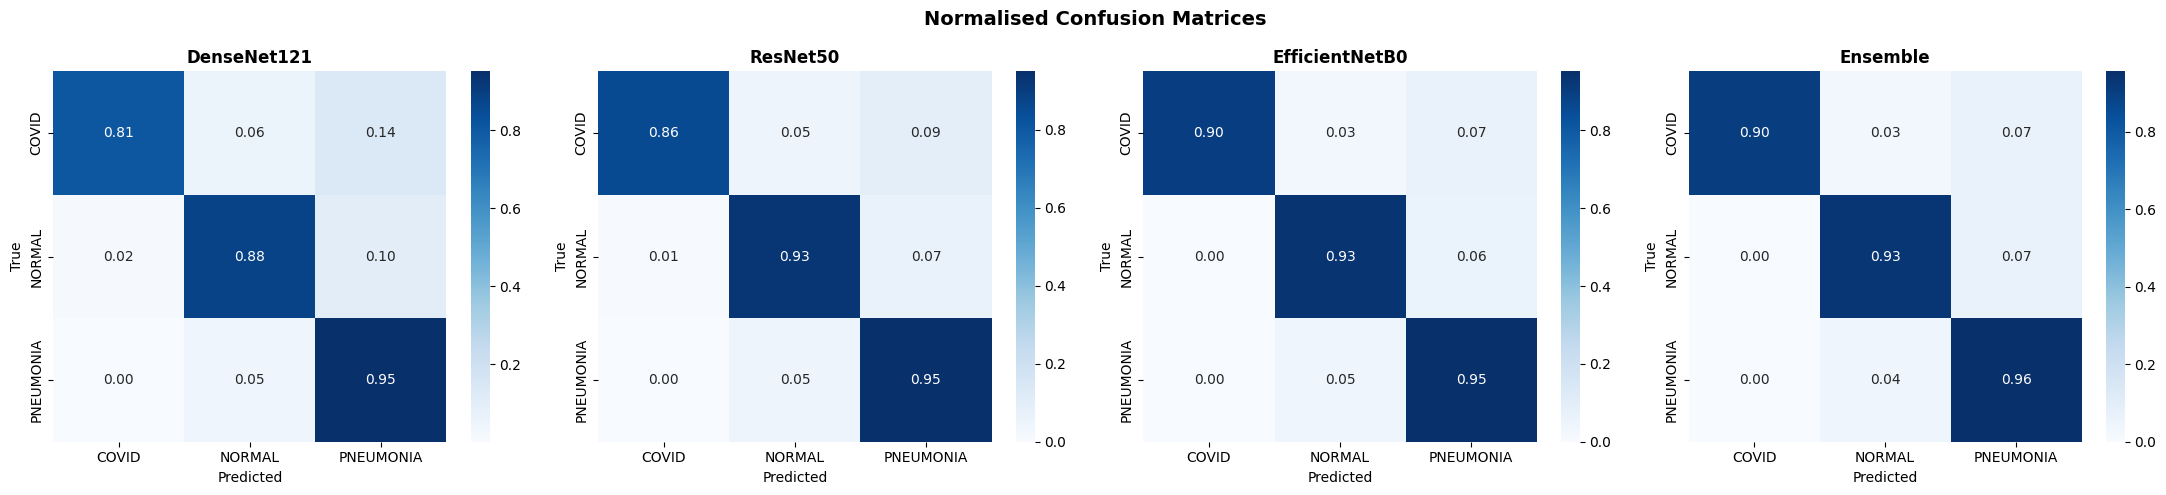

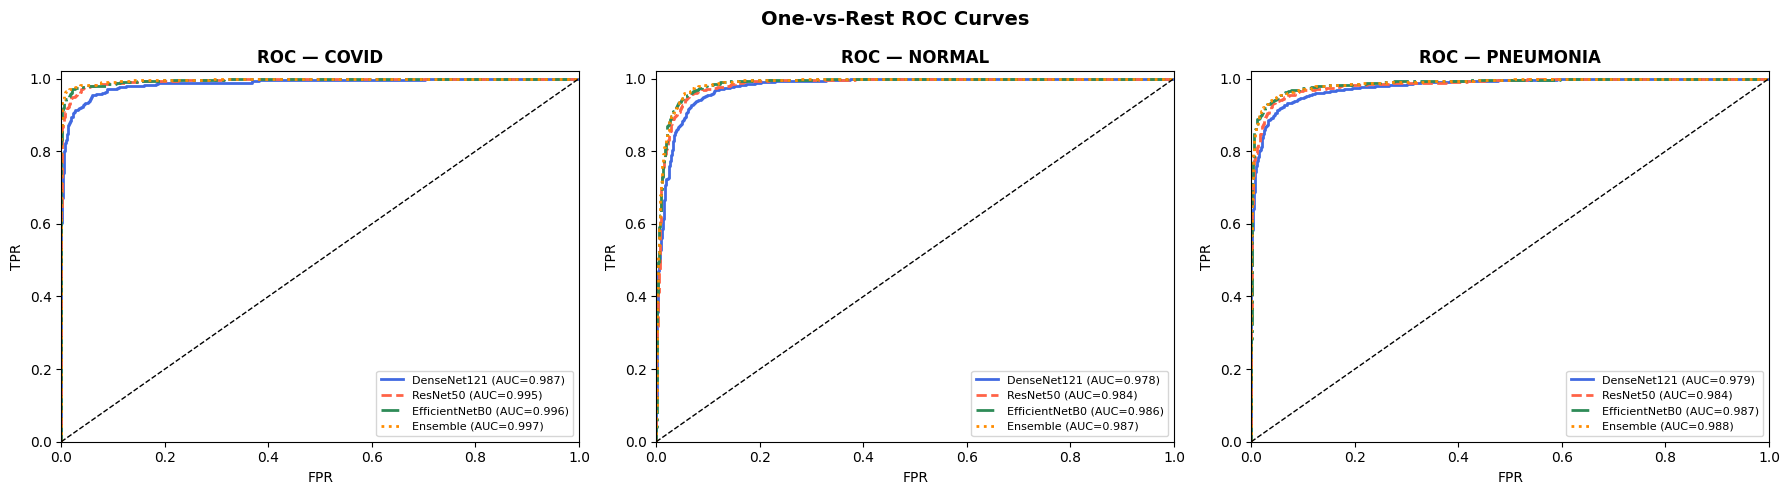

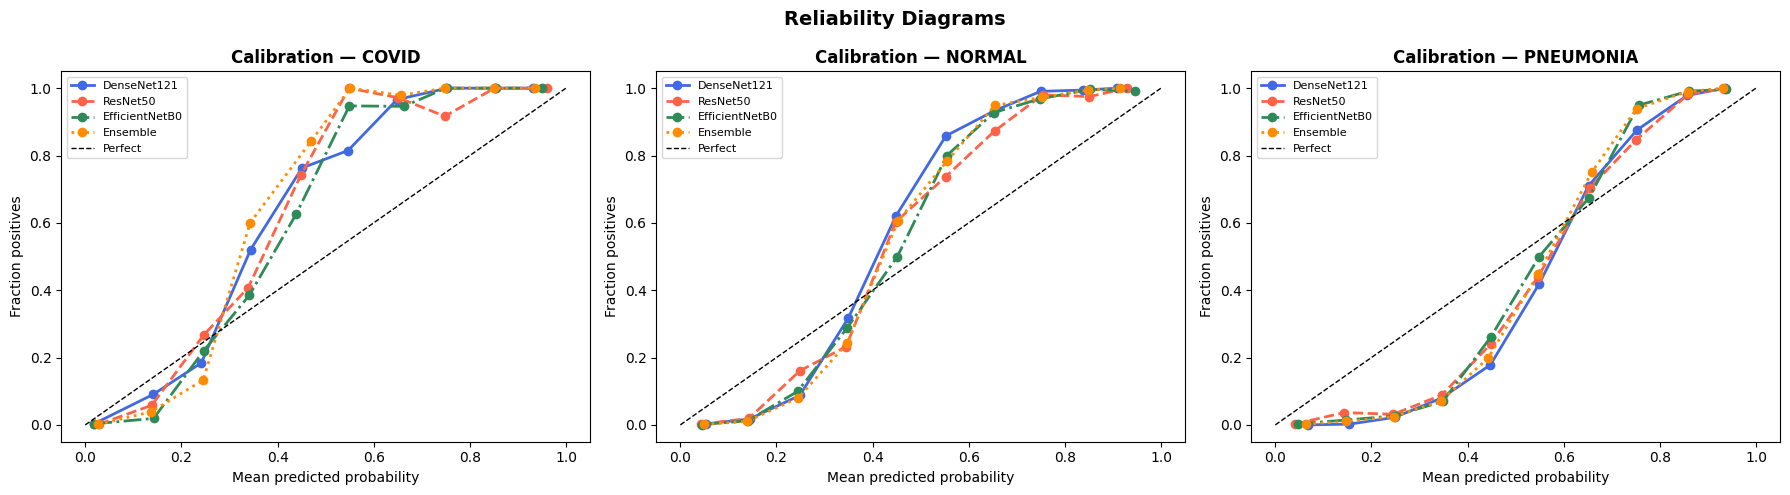

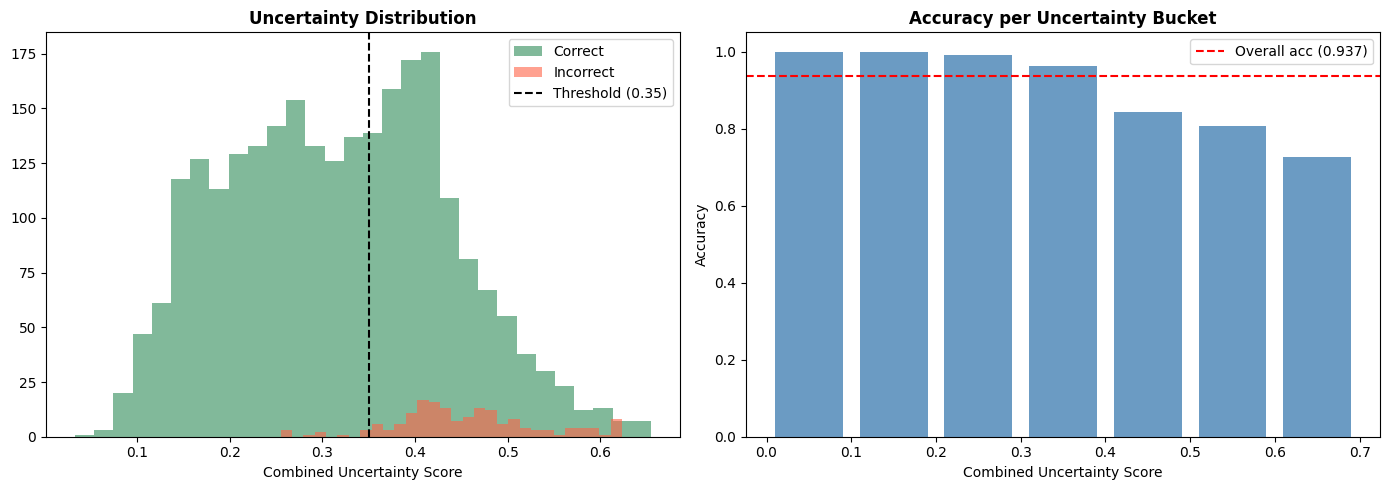

Total test images      : 2701
Referred to radiologist: 1211 (44.8%)
Accuracy (non-referred): 0.9940
Accuracy (referred)    : 0.8679  ← expect lower (hard cases)


In [11]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve

# ── Collect predictions ────────────────────────────────────────────────────────
all_results = {}
for model, name in zip(MODELS, MODEL_NAMES):
    probs = get_probs(model, test_loader)
    preds = np.argmax(probs, axis=1)
    all_results[name] = {'probs': probs, 'preds': preds}

ens_out = ensemble_predict(test_loader)
all_results['Ensemble'] = {
    'probs':        ens_out['probs'],
    'preds':        ens_out['preds'],
    'disagreement': ens_out['disagreement'],
}

# ── Metrics table ──────────────────────────────────────────────────────────────
rows = []
for name, res in all_results.items():
    probs, preds = res['probs'], res['preds']
    acc  = accuracy_score(y_test, preds)
    mauc = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')
    mf1  = f1_score(y_test, preds, average='macro')
    pf1  = f1_score(y_test, preds, average=None)
    rows.append({
        'Model':        name,
        'Accuracy':     round(acc,  4),
        'Macro AUC':    round(mauc, 4),
        'Macro F1':     round(mf1,  4),
        'F1-NORMAL':    round(pf1[CLASS_TO_IDX['NORMAL']],    4),
        'F1-PNEUMONIA': round(pf1[CLASS_TO_IDX['PNEUMONIA']], 4),
        'F1-COVID':     round(pf1[CLASS_TO_IDX['COVID']],     4),
    })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

# ── 9.2 Confusion Matrices ────────────────────────────────────────────────────
CLASS_NAMES_SORTED = [k for k, _ in sorted(CLASS_TO_IDX.items(), key=lambda x: x[1])]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, res) in zip(axes, all_results.items()):
    cm = confusion_matrix(y_test, res['preds'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES_SORTED, yticklabels=CLASS_NAMES_SORTED)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Normalised Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 9.3 ROC Curves (OvR per class) ───────────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_bin      = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
colors     = ['royalblue', 'tomato', 'seagreen', 'darkorange']
linestyles = ['-', '--', '-.', ':']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for c_idx, cls_name in enumerate(CLASS_NAMES_SORTED):
    ax = axes[c_idx]
    for (name, res), color, ls in zip(all_results.items(), colors, linestyles):
        from sklearn.metrics import roc_curve, auc as sk_auc
        fpr, tpr, _ = roc_curve(y_bin[:, c_idx], res['probs'][:, c_idx])
        auc_val = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2,
                label=f'{name} (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'ROC — {cls_name}', fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.suptitle('One-vs-Rest ROC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 9.4 Calibration Diagrams ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for c_idx, cls_name in enumerate(CLASS_NAMES_SORTED):
    ax = axes[c_idx]
    for (name, res), color, ls in zip(all_results.items(), colors, linestyles):
        frac_pos, mean_pred = calibration_curve(
            y_bin[:, c_idx], res['probs'][:, c_idx],
            n_bins=10, strategy='uniform'
        )
        ax.plot(mean_pred, frac_pos, marker='o', color=color,
                linestyle=ls, lw=2, label=name)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    ax.set_title(f'Calibration — {cls_name}', fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction positives')
    ax.legend(fontsize=8)

plt.suptitle('Reliability Diagrams', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'calibration_diagrams.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 9.5 Uncertainty Analysis ─────────────────────────────────────────────────
ens_probs  = ens_out['probs']
ens_preds  = ens_out['preds']
ens_disagr = ens_out['disagreement']

entropies, disagreements, is_correct = [], [], []
for i in range(len(y_test)):
    p       = ens_probs[i]
    ent     = float(-np.sum(p * np.log(p + 1e-8)))
    norm_e  = ent / np.log(NUM_CLASSES)
    entropies.append(norm_e)
    disagreements.append(ens_disagr[i])
    is_correct.append(ens_preds[i] == y_test[i])

combined_unc = 0.6 * np.array(entropies) + 0.4 * np.array(disagreements)
referred     = combined_unc > UNCERTAINTY_THRESHOLD
is_correct   = np.array(is_correct)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(combined_unc[is_correct],  bins=30, alpha=0.6,
             color='seagreen', label='Correct')
axes[0].hist(combined_unc[~is_correct], bins=30, alpha=0.6,
             color='tomato',   label='Incorrect')
axes[0].axvline(UNCERTAINTY_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold ({UNCERTAINTY_THRESHOLD})')
axes[0].set_title('Uncertainty Distribution', fontweight='bold')
axes[0].set_xlabel('Combined Uncertainty Score')
axes[0].legend()

buckets = np.linspace(0, 1, 11)
bucket_accs, bucket_mids = [], []
for lo, hi in zip(buckets[:-1], buckets[1:]):
    mask = (combined_unc >= lo) & (combined_unc < hi)
    if mask.sum() > 0:
        bucket_accs.append(is_correct[mask].mean())
        bucket_mids.append((lo + hi) / 2)

axes[1].bar(bucket_mids, bucket_accs, width=0.08, color='steelblue', alpha=0.8)
axes[1].axhline(is_correct.mean(), color='red', linestyle='--',
                label=f'Overall acc ({is_correct.mean():.3f})')
axes[1].set_title('Accuracy per Uncertainty Bucket', fontweight='bold')
axes[1].set_xlabel('Combined Uncertainty Score'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'uncertainty_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

n_total    = len(y_test)
n_referred = referred.sum()
acc_non_ref = is_correct[~referred].mean() if (~referred).sum() > 0 else float('nan')
acc_ref     = is_correct[referred].mean()  if referred.sum()  > 0 else float('nan')

print(f"Total test images      : {n_total}")
print(f"Referred to radiologist: {n_referred} ({n_referred/n_total*100:.1f}%)")
print(f"Accuracy (non-referred): {acc_non_ref:.4f}")
print(f"Accuracy (referred)    : {acc_ref:.4f}  ← expect lower (hard cases)")

## Stage 10 — Save Models & Config

In [12]:
model_paths = {
    'densenet121':    MODEL_DIR / 'densenet_3class.pt',
    'resnet50':       MODEL_DIR / 'resnet_3class.pt',
    'efficientnetb0': MODEL_DIR / 'efficientnet_3class.pt',
}

for (name, path), (model, mtype) in zip(
        model_paths.items(),
        zip(MODELS, MODEL_TYPES)):
    torch.save({
        'state_dict':  model.state_dict(),
        'classes':     CLASSES,
        'class_to_idx': CLASS_TO_IDX,
        'img_size':    list(IMG_SIZE),
        'num_classes': NUM_CLASSES,
        'dropout_rate': DROPOUT_RATE,
        'model_type':  mtype,
    }, str(path))
    print(f"Saved {name:20s} → {path}")

config = {
    "classes":              CLASSES,
    "class_to_idx":         CLASS_TO_IDX,
    "img_size":             list(IMG_SIZE),
    "num_classes":          NUM_CLASSES,
    "dropout_rate":         DROPOUT_RATE,
    "mc_passes":            MC_PASSES,
    "uncertainty_threshold": UNCERTAINTY_THRESHOLD,
    "ensemble_weights":     ensemble_weights.tolist(),
    "model_names":          MODEL_NAMES,
    "model_types":          MODEL_TYPES,
    "gradcam_layers":       GRADCAM_LAYERS,
    "imagenet_mean":        IMAGENET_MEAN,
    "imagenet_std":         IMAGENET_STD,
    "model_paths": {
        name: str(path) for name, path in model_paths.items()
    },
    "metrics": metrics_df.to_dict(orient='records'),
}

config_path = MODEL_DIR / 'config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"\nConfig saved → {config_path}")
print("\nAll done. Ready to launch app.py")

Saved densenet121          → C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\model\densenet_3class.pt
Saved resnet50             → C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\model\resnet_3class.pt
Saved efficientnetb0       → C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\model\efficientnet_3class.pt

Config saved → C:\Users\LENOVO\Downloads\Automated Pneumonia Detection from Chest X-Ray Images\model\config.json

All done. Ready to launch app.py
